<a href="https://colab.research.google.com/github/ayeeshamnasreen/bell-shaped-/blob/main/Predictive_Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Accuracy
---------------------
Normal Growth Business R² Score: 0.9967
High Growth Business R² Score : 0.9749

Forecast Table
   Month  Normal Growth Forecast  High Growth Forecast
0      7                  205.67                550.67
1      8                  223.24                613.24
2      9                  240.81                675.81
3     10                  258.38                738.38
4     11                  275.95                800.95
5     12                  293.52                863.52


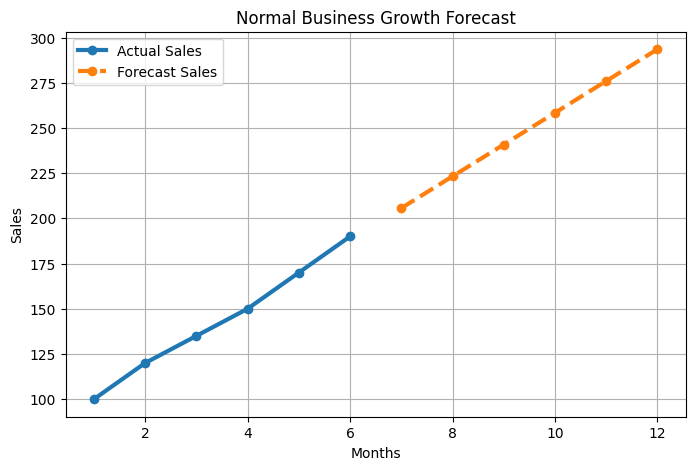

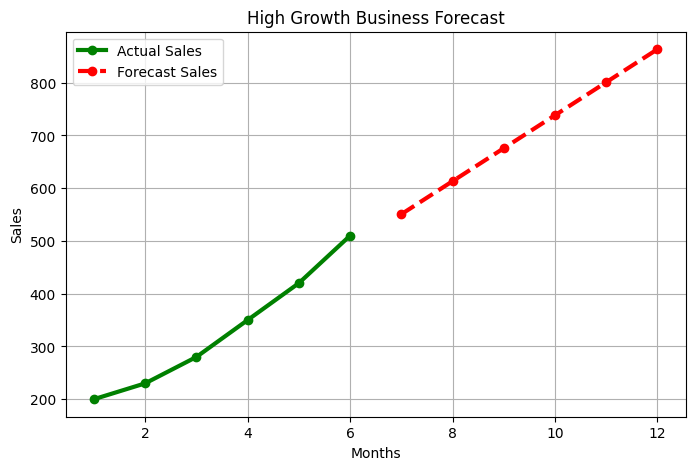

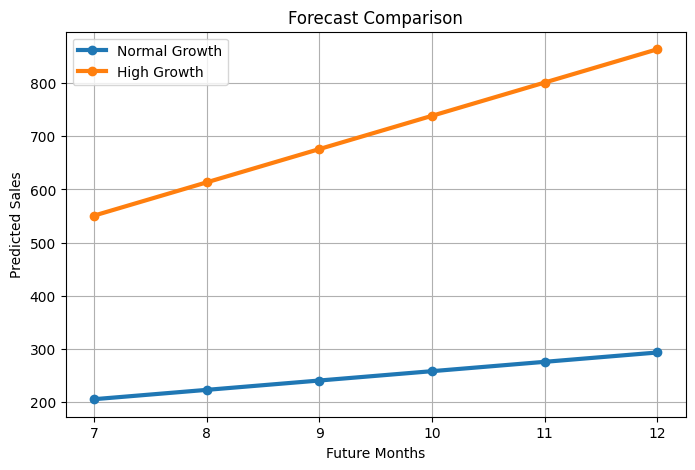

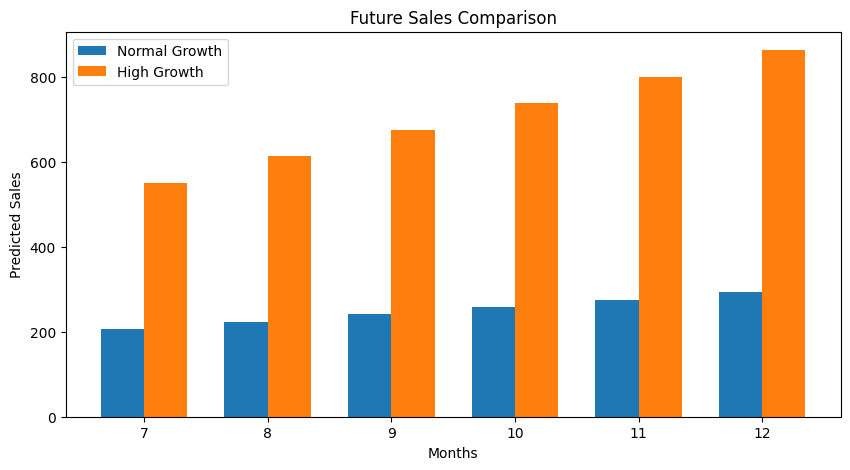

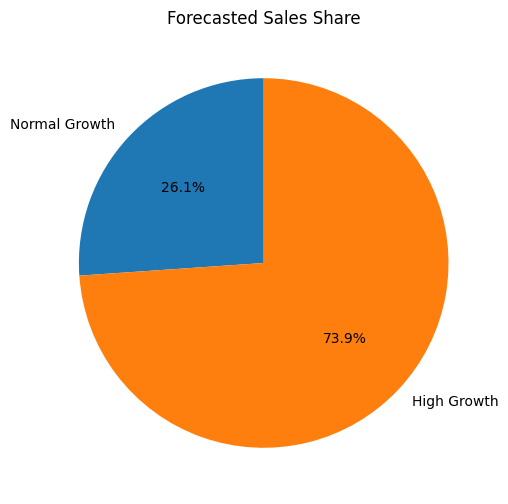

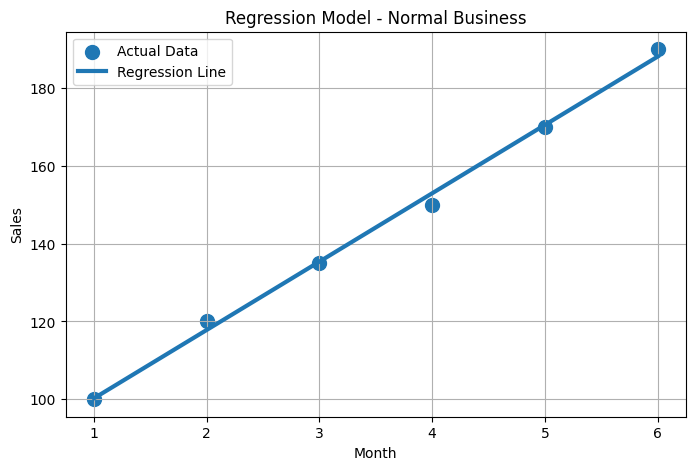

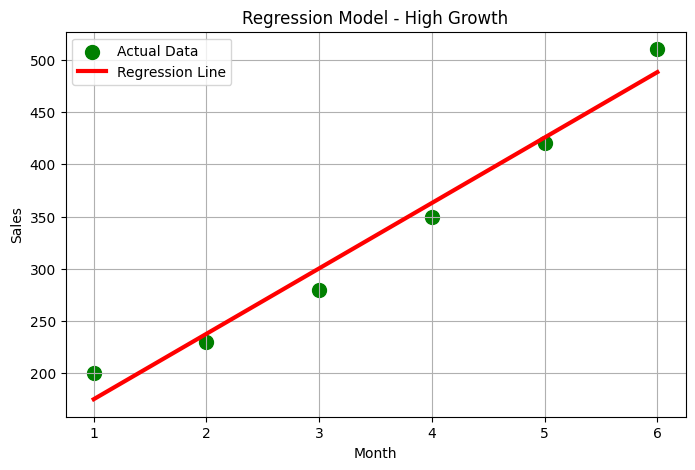


NORMAL BUSINESS FORECAST
--------------------------
Month 7 --> 205.67
Month 8 --> 223.24
Month 9 --> 240.81
Month 10 --> 258.38
Month 11 --> 275.95
Month 12 --> 293.52

HIGH GROWTH BUSINESS FORECAST
------------------------------
Month 7 --> 550.67
Month 8 --> 613.24
Month 9 --> 675.81
Month 10 --> 738.38
Month 11 --> 800.95
Month 12 --> 863.52

CSV File Saved Successfully!
File Name: sales_forecast_results.csv


In [1]:
# ============================================
# PREDICTIVE SALES FORECASTING USING ML
# ============================================

# STEP 1: IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ============================================
# STEP 2: CREATE DATASETS
# ============================================

# Dataset 1 - Normal Growth Business

months1 = np.array([1,2,3,4,5,6]).reshape(-1,1)
sales1 = np.array([100,120,135,150,170,190])

# Dataset 2 - High Growth Business

months2 = np.array([1,2,3,4,5,6]).reshape(-1,1)
sales2 = np.array([200,230,280,350,420,510])

# ============================================
# STEP 3: TRAIN MACHINE LEARNING MODELS
# ============================================

model1 = LinearRegression()
model1.fit(months1, sales1)

model2 = LinearRegression()
model2.fit(months2, sales2)

# ============================================
# STEP 4: PREDICT FUTURE SALES
# ============================================

future_months = np.array([7,8,9,10,11,12]).reshape(-1,1)

pred1 = model1.predict(future_months)
pred2 = model2.predict(future_months)

# ============================================
# STEP 5: MODEL ACCURACY
# ============================================

train_pred1 = model1.predict(months1)
train_pred2 = model2.predict(months2)

r2_1 = r2_score(sales1, train_pred1)
r2_2 = r2_score(sales2, train_pred2)

print("Model Accuracy")
print("---------------------")
print("Normal Growth Business R² Score:", round(r2_1,4))
print("High Growth Business R² Score :", round(r2_2,4))

# ============================================
# STEP 6: CREATE FORECAST TABLE
# ============================================

forecast_df = pd.DataFrame({
    'Month': [7,8,9,10,11,12],
    'Normal Growth Forecast': pred1.round(2),
    'High Growth Forecast': pred2.round(2)
})

print("\nForecast Table")
print(forecast_df)

# ============================================
# STEP 7: GRAPH 1
# NORMAL BUSINESS FORECAST
# ============================================

plt.figure(figsize=(8,5))

plt.plot(months1,
         sales1,
         marker='o',
         linewidth=3,
         label='Actual Sales')

plt.plot(future_months,
         pred1,
         marker='o',
         linestyle='dashed',
         linewidth=3,
         label='Forecast Sales')

plt.title("Normal Business Growth Forecast")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

# ============================================
# STEP 8: GRAPH 2
# HIGH GROWTH FORECAST
# ============================================

plt.figure(figsize=(8,5))

plt.plot(months2,
         sales2,
         marker='o',
         color='green',
         linewidth=3,
         label='Actual Sales')

plt.plot(future_months,
         pred2,
         marker='o',
         linestyle='dashed',
         color='red',
         linewidth=3,
         label='Forecast Sales')

plt.title("High Growth Business Forecast")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

# ============================================
# STEP 9: COMPARISON GRAPH
# ============================================

plt.figure(figsize=(8,5))

plt.plot(future_months,
         pred1,
         marker='o',
         linewidth=3,
         label='Normal Growth')

plt.plot(future_months,
         pred2,
         marker='o',
         linewidth=3,
         label='High Growth')

plt.title("Forecast Comparison")
plt.xlabel("Future Months")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(True)

plt.show()

# ============================================
# STEP 10: BAR CHART COMPARISON
# ============================================

months_labels = ['7','8','9','10','11','12']

x = np.arange(len(months_labels))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2,
        pred1,
        width,
        label='Normal Growth')

plt.bar(x + width/2,
        pred2,
        width,
        label='High Growth')

plt.xticks(x, months_labels)

plt.xlabel("Months")
plt.ylabel("Predicted Sales")
plt.title("Future Sales Comparison")
plt.legend()

plt.show()

# ============================================
# STEP 11: PIE CHART
# SALES SHARE
# ============================================

total_normal = np.sum(pred1)
total_high = np.sum(pred2)

plt.figure(figsize=(6,6))

plt.pie(
    [total_normal,total_high],
    labels=['Normal Growth','High Growth'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Forecasted Sales Share")

plt.show()

# ============================================
# STEP 12: SCATTER + REGRESSION LINE
# ============================================

plt.figure(figsize=(8,5))

plt.scatter(months1,
            sales1,
            s=100,
            label="Actual Data")

plt.plot(months1,
         train_pred1,
         linewidth=3,
         label="Regression Line")

plt.title("Regression Model - Normal Business")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

# ============================================
# STEP 13: SCATTER + REGRESSION LINE
# HIGH GROWTH
# ============================================

plt.figure(figsize=(8,5))

plt.scatter(months2,
            sales2,
            s=100,
            color='green',
            label="Actual Data")

plt.plot(months2,
         train_pred2,
         color='red',
         linewidth=3,
         label="Regression Line")

plt.title("Regression Model - High Growth")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

# ============================================
# STEP 14: PRINT ALL PREDICTIONS
# ============================================

print("\nNORMAL BUSINESS FORECAST")
print("--------------------------")

for month, sale in zip(future_months, pred1):
    print(f"Month {month[0]} --> {sale:.2f}")

print("\nHIGH GROWTH BUSINESS FORECAST")
print("------------------------------")

for month, sale in zip(future_months, pred2):
    print(f"Month {month[0]} --> {sale:.2f}")

# ============================================
# STEP 15: SAVE RESULTS TO CSV
# ============================================

forecast_df.to_csv("sales_forecast_results.csv",
                   index=False)

print("\nCSV File Saved Successfully!")
print("File Name: sales_forecast_results.csv")